### aim: Latitudinal assemblages
### date: 

In [2]:
%reset

Once deleted, variables cannot be recovered. Proceed (y/[n])?  y


In [3]:
# ================================
# IMPORTS
# ================================
import os
import glob
import pickle
import time
import warnings
from datetime import datetime
from importlib import reload

import numpy as np
import pandas as pd
import xarray as xr
import netCDF4 as nc
import seawater

import matplotlib.pyplot as plt
from matplotlib import font_manager, rcParams
import matplotlib.path as mpath

import cartopy as cp
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from cmocean import cm

# Jupyter magic
%matplotlib inline

# Suppress warnings
warnings.filterwarnings('ignore')

# ================================
# FONT CONFIGURATION
# ================================
# Disable LaTeX (use mathtext with chosen font)
plt.rcParams['text.usetex'] = False

# Base font size
fs = 11

# Path to Gill Sans
gill_sans_path = "/gpfs/home/mep22dku/scratch/FONTS/gill-sans/GillSansMedium.otf"

# Try to load custom font
if os.path.exists(gill_sans_path):
    font_manager.fontManager.addfont(gill_sans_path)
    gill_font_name = font_manager.FontProperties(fname=gill_sans_path).get_name()
    chosen_font = gill_font_name
    print(f"✓ Using custom font: {gill_font_name}")
else:
    chosen_font = "DejaVu Sans"
    print("⚠️ Gill Sans not found, using fallback: DejaVu Sans")

# Apply font settings
rcParams.update({
    'font.size': fs,
    'font.family': chosen_font,
    'axes.titlesize': fs,
    'axes.labelsize': fs,
    'xtick.labelsize': fs,
    'ytick.labelsize': fs,
    'legend.fontsize': fs,
    'mathtext.fontset': 'custom',
    'mathtext.rm': chosen_font,
    'mathtext.it': chosen_font,
    'mathtext.bf': chosen_font,
})

✓ Using custom font: Gill Sans


## runs to compare

## assorted snippets

#### notebook footer

In [4]:
def add_notebook_footer(fig, notebook_name, path_y_position=0.02):
    """
    Add notebook path as footer to figure with automatic spacing.
    
    Parameters:
    -----------
    fig : matplotlib figure object
    notebook_name : str
        Name of the notebook file (e.g., 'AMOCts.ipynb')
    path_y_position : float
        Y position for the footer text (default 0.02 = 2% from bottom)
        
    usage 
    bottom_margin = add_notebook_footer(fig, 'AMOCts.ipynb')
    plt.tight_layout(rect=[0, bottom_margin, 1, 0.96])    
    """
    notebook_path = os.path.abspath(os.getcwd())
    full_notebook_path = os.path.join(notebook_path, notebook_name)
    fig.text(0.5, path_y_position, f'Notebook: {full_notebook_path}', ha='center', 
             fontsize=10, style='italic', color='gray')
    
    # Return the bottom margin needed for tight_layout
    return path_y_position + 0.05  # Add buffer above text

In [5]:
sav = False
if sav:
    savenam = 'test2.nc'
    data_vars = {'vomecrty':(['time_counter', 'depthv', 'y', 'x'], vomecrty.values,
    {'units': 'µatm',
    'long_name':'Surface ocean pCO2'}),
    }
    # define coordinates
    coords = {'time_counter': (['time_counter'], time_counter),
            'time_centered': (['time_centered'], time_centered),
    'nav_lat': (['y','x'], nav_lat),
    'nav_lon': (['y','x'], nav_lon),
    'depthv': (['depthv'], depthv)}
    # define global attributes
    attrs = {'made in':'SOZONE/MEDUSA/makeYearlyMEDUSAsubsetfiles.ipynb',
    'desc': 'yearly medusa files, saving only variables of interest'
    }
    ds = xr.Dataset(data_vars=data_vars,
    coords=coords,
    attrs=attrs)
    ds.to_netcdf(savenam)

#### tylist

In [6]:
def make_yearlist(yrst, yrend, dtype, tr, baseDir):
    yrs = np.arange(yrst,yrend+1,1)
    ylist = []
    for i in range(0,len(yrs)):
        ty = f'{baseDir}/{tr}/ORCA2_1m_{yrs[i]}*{dtype}*.nc'
        t2 = glob.glob(ty)
        #print(t2)
        ylist.append(t2[0])
    return ylist

## runs to compare

climatologies in get_clim

In [11]:
bdir = '/gpfs/data/greenocean/software/runs/clims/'
bdir = '/gpfs/data/greenocean/software/runs//'
runs = ['TOM12_RW_OBi1', 'TOM12_TJ_R4A1', 'TOM12_TJ_LA50', 'TOM12_RY_ERA3'] #, 'TOM12_TJ_LAH3', 'TOM12_TJ_LC51']
runs = ['TOM12_TJ_LA50','TOM12_TJ_LA50','TOM12_TJ_LA50','TOM12_TJ_LA50']
runs = ['TOM12_RW_OBi1','TOM12_RW_OBi1','TOM12_RW_OBi1','TOM12_RW_OBi1']

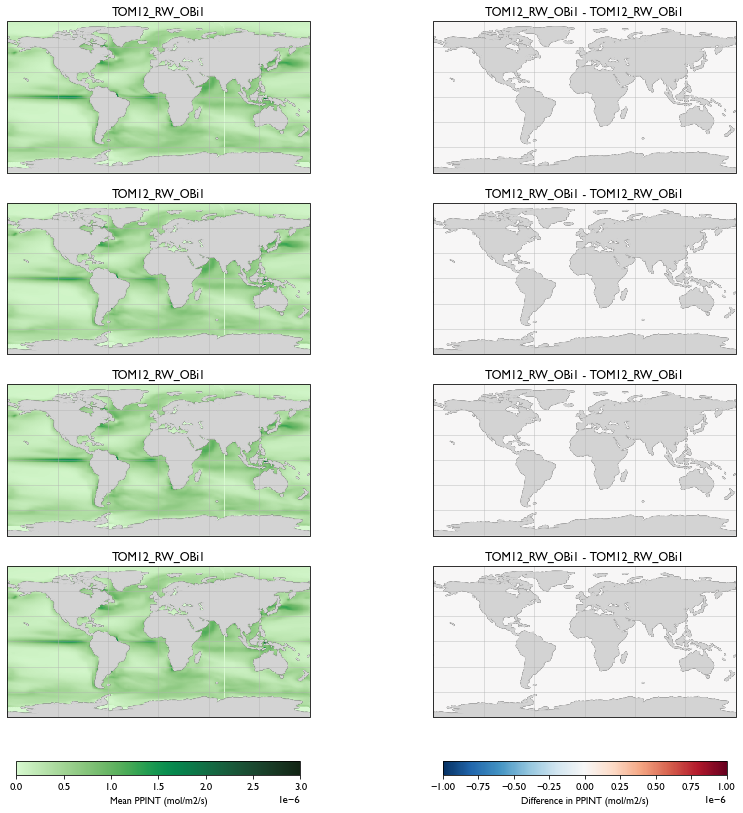

In [12]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean.cm as cm

# runs = ['TOM12_TJ_LA50', 'TOM12_TJ_LAH3', 'TOM12_TJ_LC51', 'TOM12_RY_ERA3']
# runs = ['TOM12_TJ_LA50','TOM12_TJ_LA50','TOM12_TJ_LA50','TOM12_TJ_LA50']
# runs = ['TOM12_RW_OBi1','TOM12_RW_OBi1','TOM12_RW_OBi1','TOM12_RW_OBi1']
runs = ['TOM12_RW_OBi1', 'TOM12_TJ_R4A1', 'TOM12_TJ_LA50', 'TOM12_RY_ERA3']
baserun = 'TOM12_TJ_R4A1'
clims_dir = '/gpfs/data/greenocean/software/runs/clims/'

# Load baserun
w_base = xr.open_dataset(f'{clims_dir}{baserun}/ORCA2_1m_clim_2010_2019_diad_T_rg.nc')
ppint_base = w_base.PPINT.mean(dim='time')

fig, axes = plt.subplots(len(runs), 2, figsize=(14, 4*len(runs)), 
                         subplot_kw={'projection': ccrs.PlateCarree()})

vmin = 0  # For absolute values
vmax = 3e-6  
vmin_diff = -1e-6  # For differences
vmax_diff = 1e-6

for i, run in enumerate(runs):
    w = xr.open_dataset(f'{clims_dir}{run}/ORCA2_1m_clim_2010_2019_diad_T_rg.nc')
    ppint_mean = w.PPINT.mean(dim='time')
    ppint_diff = ppint_mean - ppint_base
    
    # Left column: absolute values
    ax_left = axes[i, 0]
    pcm_left = ax_left.pcolormesh(
        ppint_mean.lon,
        ppint_mean.lat,
        ppint_mean.values,
        cmap=cm.algae,
        vmin=vmin,
        vmax=vmax,
        transform=ccrs.PlateCarree(),
        shading='auto'
    )
    ax_left.coastlines()
    ax_left.add_feature(cfeature.LAND, facecolor='lightgray', alpha=1, zorder=2)
    ax_left.gridlines(draw_labels=False, alpha=0.5)
    ax_left.set_title(f'{run}', fontsize=12)
    
    # Right column: difference from baserun
    ax_right = axes[i, 1]
    pcm_right = ax_right.pcolormesh(
        ppint_diff.lon,
        ppint_diff.lat,
        ppint_diff.values,
        cmap='RdBu_r',
        vmin=vmin_diff,
        vmax=vmax_diff,
        transform=ccrs.PlateCarree(),
        shading='auto'
    )
    ax_right.coastlines()
    ax_right.add_feature(cfeature.LAND, facecolor='lightgray', alpha=1, zorder=2)
    ax_right.gridlines(draw_labels=False, alpha=0.5)
    ax_right.set_title(f'{run} - {baserun}', fontsize=12)

# Add colorbars
cbar_left = plt.colorbar(pcm_left, ax=axes[:, 0], orientation='horizontal', pad=0.05, shrink=0.8)
cbar_left.set_label('Mean PPINT (mol/m2/s)', fontsize=10)

cbar_right = plt.colorbar(pcm_right, ax=axes[:, 1], orientation='horizontal', pad=0.05, shrink=0.8)
cbar_right.set_label('Difference in PPINT (mol/m2/s)', fontsize=10)

plt.tight_layout()
plt.show()

## depth-integrate ptrc and get surface nutrients

In [27]:
ex = False
if ex:
    bdir = '/gpfs/data/greenocean/software/runs/clims/'
    mods = ['TOM12_RW_OBi1', 'TOM12_TJ_R4A1', 'TOM12_TJ_LA50', 'TOM12_RY_ERA3']

    
    #mods = [BASE]
    ys = 2010; ye = 2019
    for mod in mods:
        print(mod)

        tvars = ['BAC', 'PRO', 'PTE', 'MES', 'GEL', 'MAC', 'DIA', 'MIX', 'COC', 'PIC', 'PHA', 'FIX',]
        w = xr.open_dataset(f'{bdir}/{mod}/ORCA2_1m_clim_{ys}_{ye}_ptrc_T.nc')
        nw = integrate_depth(w,tvars,mask)
        nw.to_netcdf(f'{bdir}/{mod}/ORCA2_1m_clim_{ys}_{ye}_ptrc_T_int.nc')    
        print(f'ORCA2_1m_clim_{ys}_{ye}_ptrc_T_int.nc')

        tvars = ['NO3', 'Si', 'PO4', 'Fer',]
        w = xr.open_dataset(f'{bdir}/{mod}/ORCA2_1m_clim_{ys}_{ye}_ptrc_T.nc')
        nw = average_top_meters(w,tvars,10)
        nw.to_netcdf(f'{bdir}/{mod}/ORCA2_1m_clim_{ys}_{ye}_ptrc_T_10m.nc')    
        print(f'ORCA2_1m_clim_{ys}_{ye}_ptrc_T_10m.nc')

        # tvars = ['LV_DIA','LV_MIX','LV_COC','LV_PIC', 'LV_PHA','LV_FIX',]
        # w = xr.open_dataset(f'{bdir}/{mod}/ORCA2_1m_clim_{ys}_{ye}_LoP_T.nc')
        # nw = average_top_meters(w,tvars,100)
        # nw.to_netcdf(f'{bdir}/{mod}/ORCA2_1m_clim_{ys}_{ye}_LoP_T_100m.nc')  
        # print(f'ORCA2_1m_clim_{ys}_{ye}_LoP_T_100m.nc')

TOM12_RW_OBi1
ORCA2_1m_clim_2010_2019_ptrc_T_int.nc
ORCA2_1m_clim_2010_2019_ptrc_T_10m.nc
TOM12_TJ_R4A1
ORCA2_1m_clim_2010_2019_ptrc_T_int.nc
ORCA2_1m_clim_2010_2019_ptrc_T_10m.nc
TOM12_TJ_LA50
ORCA2_1m_clim_2010_2019_ptrc_T_int.nc
ORCA2_1m_clim_2010_2019_ptrc_T_10m.nc
TOM12_RY_ERA3
ORCA2_1m_clim_2010_2019_ptrc_T_int.nc
ORCA2_1m_clim_2010_2019_ptrc_T_10m.nc


## calculate latitudinal profiles

#### regrid in regrid_clim as before

In [31]:
if ex: # Load masks and setup
    cdomask = xr.open_dataset('/gpfs/home/mep22dku/scratch/SOZONE/windAnalyis/wspdComponents/PlankTOMmask_regridrecalc.nc')
    tmask = cdomask.tmask
    ATL = xr.open_dataset('/gpfs/home/mep22dku/scratch/SOZONE/UTILS/mesh_mask3pt6_ATL_rg.nc')
    ATL = ATL.ATL
    ATL_csize = tmask * ATL

    # Define parameters
    bdir = '/gpfs/data/greenocean/software/runs/clims/'
    mods = ['TOM12_RW_OBi1', 'TOM12_TJ_R4A1', 'TOM12_TJ_LA50', 'TOM12_RY_ERA3']
    ys = 2010
    ye = 2019
    phy = ['DIA', 'MIX', 'COC', 'PIC', 'PHA', 'FIX']
    #'BAC', 'PRO', 'PTE', 'MES', 'GEL', 'MAC', 
    # Process each model
    for mod in mods:
        print(f'Processing {mod}...')

        # Load regridded integrated data
        dataset = xr.open_dataset(f'{bdir}{mod}/ORCA2_1m_clim_{ys}_{ye}_ptrc_T_int_rg.nc')

        # Compute latitudinal profiles
        lat_profiles = compute_latitudinal_profiles(dataset, phy, ATL_csize)

        # Save output
        output_file = f'{bdir}{mod}/ORCA2_1m_clim_{ys}_{ye}_ptrc_T_int_rg_latprof.nc'
        lat_profiles.to_netcdf(output_file)
        print(f'Saved: {output_file}')

    print('All models processed!')

Processing TOM12_RW_OBi1...
Saved: /gpfs/data/greenocean/software/runs/clims/TOM12_RW_OBi1/ORCA2_1m_clim_2010_2019_ptrc_T_int_rg_latprof.nc
Processing TOM12_TJ_R4A1...
Saved: /gpfs/data/greenocean/software/runs/clims/TOM12_TJ_R4A1/ORCA2_1m_clim_2010_2019_ptrc_T_int_rg_latprof.nc
Processing TOM12_TJ_LA50...
Saved: /gpfs/data/greenocean/software/runs/clims/TOM12_TJ_LA50/ORCA2_1m_clim_2010_2019_ptrc_T_int_rg_latprof.nc
Processing TOM12_RY_ERA3...
Saved: /gpfs/data/greenocean/software/runs/clims/TOM12_RY_ERA3/ORCA2_1m_clim_2010_2019_ptrc_T_int_rg_latprof.nc
All models processed!


## plot latitudinal profiles

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


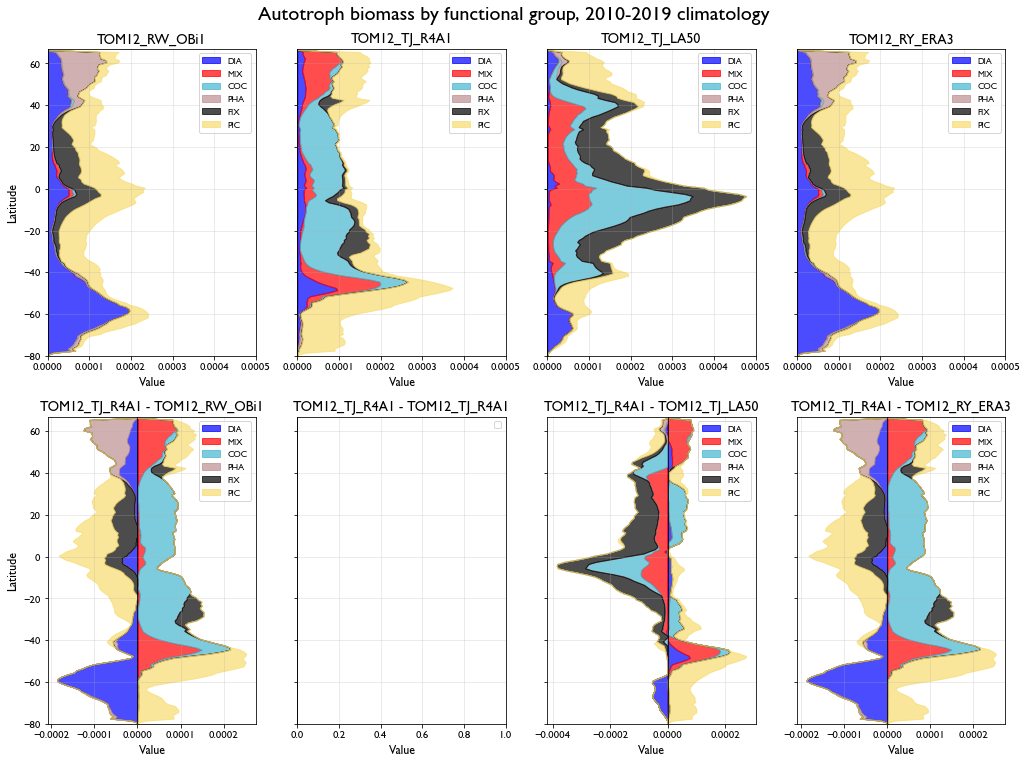

Plot created successfully!


In [37]:
import matplotlib.pyplot as plt
import xarray as xr

# Load the latitudinal profile datasets
bdir = '/gpfs/data/greenocean/software/runs/clims/'
mods = ['TOM12_RW_OBi1', 'TOM12_TJ_R4A1', 'TOM12_TJ_LA50', 'TOM12_RY_ERA3']
ys = 2010
ye = 2019

# Load datasets
datasets = {}
for mod in mods:
    datasets[mod] = xr.open_dataset(f'{bdir}{mod}/ORCA2_1m_clim_{ys}_{ye}_ptrc_T_int_rg_latprof.nc')

# Base run
baserun = 'TOM12_TJ_R4A1'
D_base = datasets[baserun]

stit = 'Autotroph biomass by functional group, 2010-2019 climatology'

# Settable colors list
colors = ['b', 'r', '#45B7D1', 'rosybrown', 'k', '#F7DC6F']

# Variable names
variable_names = ['DIA', 'MIX', 'COC', 'PHA', 'FIX', 'PIC']

# Create figure with 2 rows, 4 columns
fact = 0.6
fig, axes = plt.subplots(2, 4, figsize=(24*fact, 18*fact), sharey=True)

# Get latitude values
lat = D_base['lat'].values

# Top row: plot each dataset
for i, mod in enumerate(mods):
    plot_stacked(axes[0, i], datasets[mod], lat, variable_names, colors, mod)

# Bottom row: differences from baserun
for i, mod in enumerate(mods):
    DIFF = D_base - datasets[mod]
    plot_stacked(axes[1, i], DIFF, lat, variable_names, colors, f'{baserun} - {mod}')

# Set y-axis labels only for leftmost plots
axes[0, 0].set_ylabel('Latitude', fontsize=12)
axes[1, 0].set_ylabel('Latitude', fontsize=12)

# Set y-limits for all plots
for ax in axes.flatten():
    ax.set_ylim(-80, 67)

# Set x-limits for top row (absolute values)
for i in range(4):
    axes[0, i].set_xlim([0, 0.0005])

fig.suptitle(stit, fontsize=20)
plt.tight_layout()
plt.savefig('./plts/PHY_stacked_latitude_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("Plot created successfully!")

## checking OBA series runs

In [7]:
ex = False
if ex: # Load masks and setup
    cdomask = xr.open_dataset('/gpfs/home/mep22dku/scratch/SOZONE/windAnalyis/wspdComponents/PlankTOMmask_regridrecalc.nc')
    tmask = cdomask.tmask
    ATL = xr.open_dataset('/gpfs/home/mep22dku/scratch/SOZONE/UTILS/mesh_mask3pt6_ATL_rg.nc')
    ATL = ATL.ATL
    ATL_csize = tmask * ATL

    # Define parameters
    bdir = '/gpfs/data/greenocean/users/mep22dku/clims/'
    mods = ['TOM12_TJ_OBA1', 'TOM12_TJ_OBC1']# 'TOM12_TJ_OBH1']#, 'TOM12_RY_ERA3']
    # mods = 
    ys = 1925
    ye = 1934
    phy = ['DIA', 'MIX', 'COC', 'PIC', 'PHA', 'FIX']
    #'BAC', 'PRO', 'PTE', 'MES', 'GEL', 'MAC', 
    # Process each model
    for mod in mods:
        print(f'Processing {mod}...')

        # Load regridded integrated data
        dataset = xr.open_dataset(f'{bdir}{mod}/ORCA2_1m_clim_{ys}_{ye}_ptrc_T_int_rg.nc')

        # Compute latitudinal profiles
        lat_profiles = compute_latitudinal_profiles(dataset, phy, ATL_csize)

        # Save output
        output_file = f'{bdir}{mod}/ORCA2_1m_clim_{ys}_{ye}_ptrc_T_int_rg_latprof.nc'
        lat_profiles.to_netcdf(output_file)
        print(f'Saved: {output_file}')

    print('All models processed!')

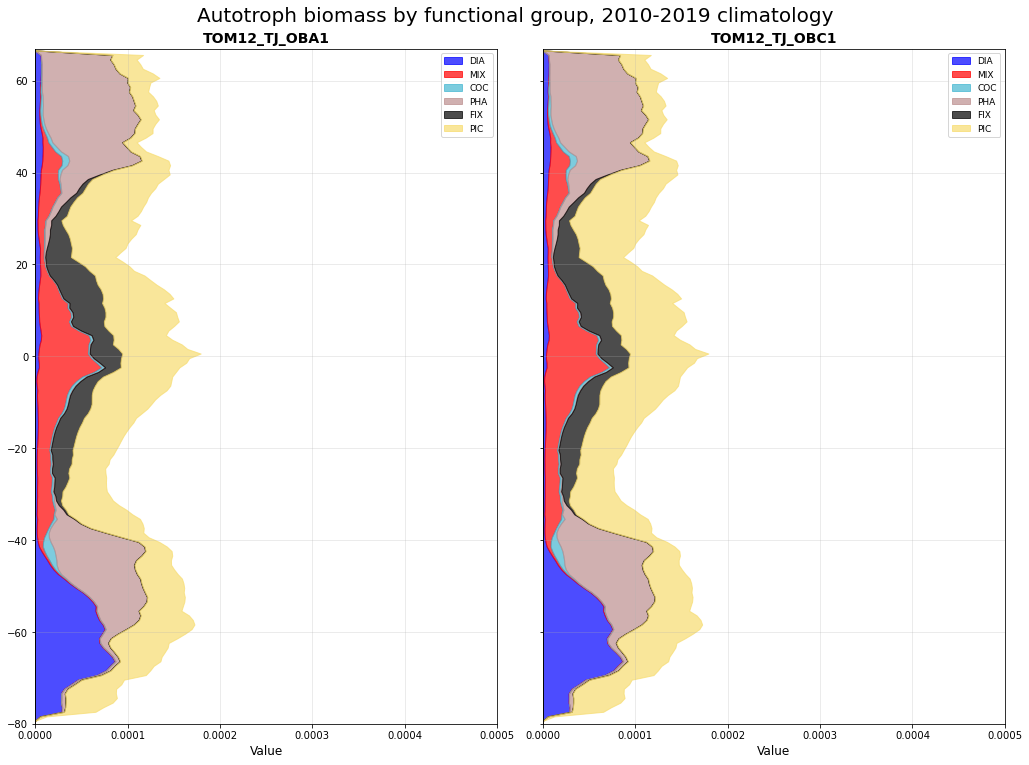

Plot created successfully!


In [15]:
import matplotlib.pyplot as plt
import xarray as xr

# Load the latitudinal profile datasets
bdir = '/gpfs/data/greenocean/users/mep22dku/clims/'
mods = ['TOM12_TJ_OBA1', 'TOM12_TJ_OBC1']#, 'TOM12_TJ_LA50', 'TOM12_RY_ERA3']
ys = 1925
ye = 1934

# Load datasets
datasets = {}
for mod in mods:
    datasets[mod] = xr.open_dataset(f'{bdir}{mod}/ORCA2_1m_clim_{ys}_{ye}_ptrc_T_int_rg_latprof.nc')

# Base run
baserun = 'TOM12_TJ_OBA1'
D_base = datasets[baserun]

stit = 'Autotroph biomass by functional group, 2010-2019 climatology'

# Settable colors list
colors = ['b', 'r', '#45B7D1', 'rosybrown', 'k', '#F7DC6F']

# Variable names
variable_names = ['DIA', 'MIX', 'COC', 'PHA', 'FIX', 'PIC']

# Create figure with 2 rows, 4 columns
fact = 0.6
fig, axes = plt.subplots(1, 2, figsize=(24*fact, 18*fact), sharey=True)

# Get latitude values
lat = D_base['lat'].values

# Top row: plot each dataset
for i, mod in enumerate(mods):
    plot_stacked(axes[i], datasets[mod], lat, variable_names, colors, mod)

# # Bottom row: differences from baserun
# for i, mod in enumerate(mods):
#     DIFF = D_base - datasets[mod]
#     plot_stacked(axes[1, i], DIFF, lat, variable_names, colors, f'{baserun} - {mod}')

# Set y-axis labels only for leftmost plots
#axes[0, 0].set_ylabel('Latitude', fontsize=12)
#axes[1, 0].set_ylabel('Latitude', fontsize=12)

# Set y-limits for all plots
for ax in axes.flatten():
    ax.set_ylim(-80, 67)

# Set x-limits for top row (absolute values)
for i in range(2):
    axes[i].set_xlim([0, 0.0005])

fig.suptitle(stit, fontsize=20)
plt.tight_layout()
#plt.savefig('./plts/PHY_stacked_latitude_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("Plot created successfully!")

## help fxn

In [13]:
def integrate_depth(dataset, var_list, tmesh, suffix='_int'):
    """
    Integrate 4D variables along depth dimension to create 3D variables.
    
    Parameters
    ----------
    dataset : xr.Dataset
        Input dataset with 4D variables (time, depth, y, x)
    var_list : list of str
        Names of variables to integrate
    tmesh : xr.Dataset
        Meshmask dataset containing cell thickness (e3t_0)
    suffix : str, optional
        Suffix to append to integrated variable names (default: '_int')
        Note: This parameter is kept for backwards compatibility but is not used
        
    Returns
    -------
    xr.Dataset
        Dataset containing only integrated versions of variables from var_list
    """
    
    # Find the time dimension name
    time_dim = None
    for var in var_list:
        if var in dataset.data_vars:
            dims = dataset[var].dims
            # Assume first dimension is time
            time_dim = dims[0]
            break
    
    if time_dim is None:
        raise ValueError(f"Could not find time dimension in variables: {var_list}")
    
    # Find the depth dimension name (typically 'deptht', 'depth', 'z', etc.)
    depth_dim = None
    for var in var_list:
        if var in dataset.data_vars:
            dims = dataset[var].dims
            if len(dims) >= 2:  # Should be 4D
                depth_dim = dims[1]
            break
    
    if depth_dim is None:
        raise ValueError(f"Could not find depth dimension in variables: {var_list}")
    
    # Get cell thickness (e3t) and rename dimensions to match dataset
    e3t = tmesh['e3t_0'].copy()
    
    # Rename tmesh dimensions to match dataset dimensions
    dim_mapping = {}
    if 't' in e3t.dims:
        dim_mapping['t'] = time_dim
    if 'z' in e3t.dims:
        dim_mapping['z'] = depth_dim
    
    if dim_mapping:
        e3t = e3t.rename(dim_mapping)
    
    # Handle time dimension: squeeze if singleton, then broadcast if needed
    if time_dim in e3t.dims and e3t.sizes[time_dim] == 1:
        e3t = e3t.squeeze(time_dim, drop=True)
    
    # If e3t doesn't have the dataset's time dimension, add it
    if time_dim not in e3t.dims and time_dim in dataset.dims:
        e3t = e3t.expand_dims({time_dim: dataset[time_dim]})
    
    # Create empty output dataset
    output_ds = xr.Dataset()
    
    # Integrate each variable
    for var in var_list:
        if var not in dataset.data_vars:
            print(f"Warning: variable {var} not found in dataset")
            continue
        
        # Broadcast e3t to match variable dimensions
        e3t_broadcasted = xr.broadcast(dataset[var], e3t)[1]
        
        # Depth-integrated values
        integrated = (dataset[var] * e3t_broadcasted).sum(dim=depth_dim)
        
        # Add to output dataset without suffix
        output_ds[var] = integrated
    
    return output_ds

In [1]:
import xarray as xr

def compute_latitudinal_profiles(ds, variables, mask, lon_dim='lon', time_dim='time'):
    """
    Compute latitudinal profiles for given variables.
    
    Parameters
    ----------
    ds : xarray.Dataset
        Input dataset containing the variables
    variables : list of str
        List of variable names to compute profiles for
    mask : xarray.DataArray
        Spatial mask for weighted averaging (e.g., ATL_csize)
    lon_dim : str, optional
        Name of longitude dimension (default: 'lon')
    time_dim : str, optional
        Name of time dimension (default: 'time')
    
    Returns
    -------
    xarray.Dataset
        Dataset with latitudinal profiles for each variable
    """
    lat_profiles = {}
    
    for var in variables:
        # Average over time
        time_avg = ds[var].mean(time_dim)
        
        # Average over longitudes at each latitude, weighted by mask
        lat_profile = (time_avg * mask).sum(lon_dim) / mask.sum(lon_dim)
        
        # Store in dictionary
        lat_profiles[var] = lat_profile
    
    # Combine into dataset
    return xr.Dataset(lat_profiles)



In [26]:
def average_top_meters(dataset, var_list, depth_meters):
    """
    Average 4D variables over the top x meters to create 3D variables.
    
    Parameters
    ----------
    dataset : xr.Dataset
        Input dataset with 4D variables (time, depth, y, x)
    var_list : list of str
        Names of variables to average
    depth_meters : int or float
        Depth in meters over which to average (e.g., 100 for top 100m)
        
    Returns
    -------
    xr.Dataset
        Dataset containing only averaged versions of variables from var_list
    """
    
    # Load meshmask
    tmesh = xr.open_dataset('/gpfs/data/greenocean/software/resources/regrid/mesh_mask3_6.nc')
    
    # Find the time dimension name
    time_dim = None
    for var in var_list:
        if var in dataset.data_vars:
            dims = dataset[var].dims
            time_dim = dims[0]
            break
    
    if time_dim is None:
        raise ValueError(f"Could not find time dimension in variables: {var_list}")
    
    # Find the depth dimension name
    depth_dim = None
    for var in var_list:
        if var in dataset.data_vars:
            dims = dataset[var].dims
            if len(dims) >= 2:  # Should be 4D
                depth_dim = dims[1]
            break
    
    if depth_dim is None:
        raise ValueError(f"Could not find depth dimension in variables: {var_list}")
    
    # Get depth coordinates and cell thickness
    depths = dataset[depth_dim].values
    e3t = tmesh['e3t_0'].copy()
    
    # Rename tmesh dimensions to match dataset dimensions
    dim_mapping = {}
    if 't' in e3t.dims:
        dim_mapping['t'] = time_dim
    if 'z' in e3t.dims:
        dim_mapping['z'] = depth_dim
    
    if dim_mapping:
        e3t = e3t.rename(dim_mapping)
    
    # Handle time dimension: squeeze if singleton, then broadcast if needed
    if time_dim in e3t.dims and e3t.sizes[time_dim] == 1:
        e3t = e3t.squeeze(time_dim, drop=True)
    
    # If e3t doesn't have the dataset's time dimension, add it
    if time_dim not in e3t.dims and time_dim in dataset.dims:
        e3t = e3t.expand_dims({time_dim: dataset[time_dim]})
    
    # Find indices where depth <= depth_meters
    depth_mask = depths <= depth_meters
    depth_indices = [i for i, mask in enumerate(depth_mask) if mask]
    
    if not depth_indices:
        raise ValueError(f"No depths found <= {depth_meters} meters")
    
    # Create empty output dataset
    output_ds = xr.Dataset()
    
    # Average each variable over the selected depth range
    for var in var_list:
        if var not in dataset.data_vars:
            print(f"Warning: variable {var} not found in dataset")
            continue
        
        # Select data within the depth range
        var_subset = dataset[var].isel({depth_dim: depth_indices})
        e3t_subset = e3t.isel({depth_dim: depth_indices})
        
        # Broadcast e3t to match variable dimensions
        e3t_broadcasted = xr.broadcast(var_subset, e3t_subset)[1]
        
        # Depth-weighted average
        weighted_sum = (var_subset * e3t_broadcasted).sum(dim=depth_dim)
        total_thickness = e3t_broadcasted.sum(dim=depth_dim)
        averaged = weighted_sum / total_thickness
        
        # Add to output dataset without suffix
        output_ds[var] = averaged
    
    return output_ds

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager, rcParams
import matplotlib.path as mpath

def plot_stacked(ax, DS, lat, variable_names, colors, title):
    cumulative_pos = np.zeros(len(lat))  # For positive values (stack right)
    cumulative_neg = np.zeros(len(lat))  # For negative values (stack left)
    
    for i, var in enumerate(variable_names):
        var_data = DS[var].values
        
        # Create masks for where values are positive vs negative
        pos_mask = var_data > 0
        neg_mask = var_data < 0
        
        has_pos = np.any(pos_mask)
        has_neg = np.any(neg_mask)
        
        # For positive values: stack to the right
        if has_pos:
            # Start from cumulative_pos, add var_data only where positive
            left_edge_pos = cumulative_pos.copy()
            right_edge_pos = cumulative_pos.copy()
            right_edge_pos[pos_mask] = cumulative_pos[pos_mask] + var_data[pos_mask]
            
            ax.fill_betweenx(
                lat, 
                left_edge_pos, 
                right_edge_pos,
                color=colors[i],
                alpha=0.7,
                label=var
            )
            # Update cumulative only where values were positive
            cumulative_pos[pos_mask] += var_data[pos_mask]
        
        # For negative values: stack to the left
        if has_neg:
            # Start from cumulative_neg, add var_data only where negative
            left_edge_neg = cumulative_neg.copy()
            right_edge_neg = cumulative_neg.copy()
            right_edge_neg[neg_mask] = cumulative_neg[neg_mask] + var_data[neg_mask]
            
            ax.fill_betweenx(
                lat, 
                left_edge_neg, 
                right_edge_neg,
                color=colors[i],
                alpha=0.7,
                label=None if has_pos else var  # Only label if not already labeled
            )
            # Update cumulative only where values were negative
            cumulative_neg[neg_mask] += var_data[neg_mask]
    
    ax.set_xlabel('Value', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(loc='best', frameon=True, fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.axvline(x=0, color='black', linewidth=0.8, linestyle='-')